In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets
from ipywidgets import interact,interact_manual
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('cleaned_naukri.csv')

In [3]:
df.head()

,company,education,industry,jobdescription,joblocation_address,jobtitle,numberofpositions,payrate,postdate,skills,temp2,min_experience,max_experience
0,MM Media Pvt Ltd,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,Media,Job Description Send me Jobs like this Quali...,Chennai,Walkin Data Entry Operator (night Shift),1,"1,50,000 - 2,25,000 P.A",2016-05-21,ITES,1,0.0,1.0
1,find live infotech,UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...,Advertising,Job Description Send me Jobs like this Quali...,Chennai,Work Based Onhome Based Part Time.,60,"1,50,000 - 2,50,000 P.A. 20000",2016-05-21,Marketing,1,0.0,0.0
2,Softtech Career Infosystem Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any P...,IT-Software,Job Description Send me Jobs like this - as ...,Bangalore,Pl/sql Developer - SQL,1,Not Disclosed by Recruiter,2016-10-13,(IT) Application Programming,1,4.0,8.0
3,Onboard HRServices LLP,UG: Any Graduate - Any Specialization PG:CA Do...,Banking,Job Description Send me Jobs like this - Inv...,Mumbai,Manager/ad/partner - Indirect Tax - CA,1,Not Disclosed by Recruiter,2016-10-13,Accounts,1,11.0,15.0
4,Onboard HRServices LLP,UG: Any Graduate - Any Specialization PG:CA Do...,Banking,Job Description Send me Jobs like this - Inv...,Bangalore,Manager/ad/partner - Indirect Tax - CA,1,Not Disclosed by Recruiter,2016-10-13,Accounts,1,11.0,15.0


In [4]:
for i in ['company','industry','skills','joblocation_address','jobtitle']:
    print(f'There are -> {df[i].nunique()}   unique values in the {i} varable.')

There are -> 8455   unique values in the company varable.
There are -> 61   unique values in the industry varable.
There are -> 45   unique values in the skills varable.
There are -> 300   unique values in the joblocation_address varable.
There are -> 17455   unique values in the jobtitle varable.


In [5]:
total_jobs=df['numberofpositions'].sum()
print(f'There are {total_jobs} jobs in the dataset')

There are 204970 jobs in the dataset


In [6]:
wc_cols=['company','jobtitle']
def get_words(series):    
    words=[]
    for text in series:
        text=str(text)
        if text.lower().strip() not in ['hiring for','opening for','opening for','bangalore','urgent opening','opening','hiring']:
            text=text.strip().lower()
            words.append(text.strip().title())  
    return words
company_words=get_words(df['company'])
jobtitle_words=get_words(df['jobtitle'])


In [11]:
# use consistant, title cate, in company column
df['company']=df['company'].str.title()

In [7]:
import wordcloud
from wordcloud import WordCloud

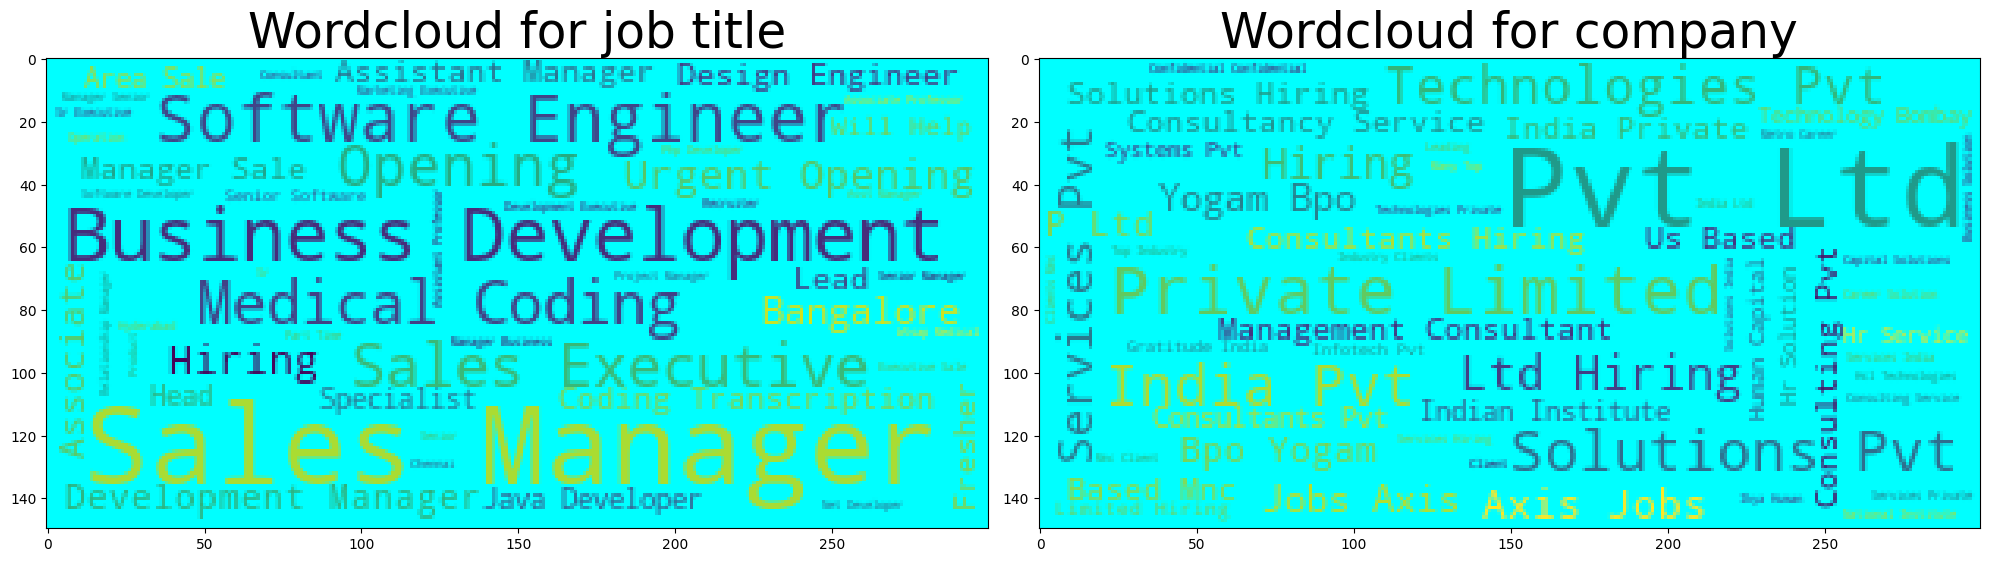

In [12]:
plt.figure(figsize=(20,10))
titles=['job title','company']
for i,v in enumerate([jobtitle_words, company_words]):
    plt.subplot(1,2,i+1)
    wordcloud = WordCloud(max_font_size=35, width=300, height=150, background_color = 'cyan').generate(' '.join(v))
    plt.imshow(wordcloud)
    plt.title(f"Wordcloud for {titles[i]}", fontsize=35)
    
plt.tight_layout()
plt.show()


In [15]:
pldf=df.copy()
pldf['company']=pldf['company'].str[:30]

In [ ]:
@interact
def tops(top_n=[i for i in range(5,31,5)]):
    data = pldf.groupby('company')['numberofpositions'].sum().sort_values(ascending=False).head(top_n) 
    plt.figure(figsize=(14,int(top_n/1.5)))
    sns.barplot(x=data.values, y=data.index, palette='inferno')
    plt.title(f"Top {top_n} Companies with the Most Openings")
    plt.grid()
    plt.xticks(rotation=75,fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='top_n', options=(5, 10, 15, 20, 25, 30), value=5), Output()), _dom…

In [18]:
pd.set_option('display.max_rows',150)
@interact
def check(City=sorted(list([i for i in df['joblocation_address'].unique() if pd.notna(i)])),
          Industry=sorted(list(df['industry'].unique())),
          Experience=list(df['min_experience'].value_counts().sort_values(ascending=False).index),
        Vacancies=10):
    return df.loc[(df['numberofpositions']>Vacancies)&
                  (df['industry']==Industry)&
                  (df['min_experience']==Experience)][[
                      'company',
                      'jobtitle',
                      'education',
                      'payrate',
                      'numberofpositions']].sort_values(by='numberofpositions',ascending=False)


interactive(children=(Dropdown(description='City', options=('Adilabad', 'Agartala', 'Agra', 'Ahmedabad', 'Airo…

In [29]:
def srp(x):
    return x.strip()
df['industry']=df['industry'].apply(srp)

In [30]:
x=pd.crosstab(df['education'],df['industry'])
x

industry,Accounting,Advertising,Agriculture,Animation,Architecture,Automobile,Aviation,BPO,Banking,Brewery,...,Security,Semiconductors,Shipping,Strategy,Telecom,Textiles,Travel,Tyres,Water Treatment,Wellness
education,,,,,,,,,,,,,,,,,,,,,
Doctorate:Any Doctorate - Any Specialization,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Doctorate:Doctorate Not Required,0,0,0,0,0,3,0,32,0,0,...,0,0,0,0,0,0,2,0,0,0
PG:Any Postgraduate,0,0,0,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
PG:Any Postgraduate - Any Specialization,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"UG: Other Graduate, Any Graduate, Graduation Not Required, B.A PG:Any Postgraduate, Post Graduation Not Required, Other, CA Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required",0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
"UG: Other Graduate, B.Sc - Any Specialization, B.Com - Commerce, Diploma - Any Specialization, B.Tech/B.E. - Any Specialization, B.A - Any Specialization, B.B.A - Management PG:Any Postgraduate - Any Specialization, Post Graduation Not Required Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"UG: Other Graduate, B.Tech/B.E. - Any Specialization, B.B.A / B.M.S - Management, B.Com - Commerce, B.Sc - Any Specialization, Diploma - Any Specialization, B.A - Any Specialization, BCA - Computers, B.Ed - Education, BHM - Hotel Management PG:Other, PG Diploma - Any Specialization",0,0,0,0,0,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
@interact
def recommendation_job_industry(Industry=list(df['industry'].value_counts().index)):
    job = x[Industry]
    similar_jobs=x.corrwith(job)
    similar_jobs=similar_jobs.sort_values(ascending=False)
    similar_jobs=similar_jobs.iloc[1:]
    similar_jobs=similar_jobs.head(5)
    return similar_jobs

interactive(children=(Dropdown(description='Industry', options=('IT-Software', 'BPO', 'Banking', 'Education', …